<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Impute Missing Values**


This exercise will practice essential data wrangling techniques using the Stack Overflow survey dataset. The primary focus is on handling missing data and ensuring data quality:

- **Load the Data:** Import the dataset into a DataFrame using the pandas library.

- **Clean the Data:** Identify and remove duplicate entries to maintain data integrity.

- **Handle Missing Values:** Detect missing values, impute them with appropriate strategies, and verify the imputation to create a complete and reliable dataset for analysis.



## Objectives


-   Identify missing values in the dataset.

-   Apply techniques to impute missing values in the dataset.
  
-   Use suitable techniques to normalize data in the dataset.


-----


#### Install needed library


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

### Step 1: Import Required Libraries


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2: Load the Dataset Into a Dataframe


#### **Read Data**
<p>
The functions below will download the dataset into your browser:
</p>


In [5]:

file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())
print(df.columns)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

### Step 3. Finding and Removing Duplicates
##### Task 1: Identify duplicate rows in the dataset.


In [11]:
dupp_row = df[df.duplicated()]
#dupp_row = df[df.duplicated(keep=False)]
print(dupp_row)
print("Number of duplicate row", df.duplicated().sum())
print(df.duplicated().any())


       ResponseId                                         MainBranch  \
65437           1                     I am a developer by profession   
65438           2                     I am a developer by profession   
65439           3                     I am a developer by profession   
65440           4                              I am learning to code   
65441           5                     I am a developer by profession   
65442           6                        I code primarily as a hobby   
65443           7  I am not primarily a developer, but I write co...   
65444           8                              I am learning to code   
65445           9                        I code primarily as a hobby   
65446          10                     I am a developer by profession   

                      Age                                         Employment  \
65437  Under 18 years old                                Employed, full-time   
65438     35-44 years old                      

##### Task 2: Remove the duplicate rows from the dataframe.



In [12]:
df = df.drop_duplicates()

print(df.duplicated().any())
print(df.duplicated().sum())

False0

### Step 4: Finding Missing Values
##### Task 3: Find the missing values for all columns.


In [14]:
missing_col = df.isnull().sum()
#print(missing_col)
missing_col= missing_col[missing_col>0]
#print(df.isnull().sum()[df.isnull().sum() > 0])
print(missing_col)

RemoteWork             10631
CodingActivities       10971
EdLevel                 4653
LearnCode               4949
LearnCodeOnline        16200
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 109, dtype: int64

##### Task 4: Find out how many rows are missing in the column RemoteWork.


In [15]:
col_remote = df["RemoteWork"].isnull().sum()
print(col_remote)
#print("RemoteWork Missing", df["RemoteWork"].isnull().sum())

10631

### Step 5. Imputing Missing Values
##### Task 5: Find the value counts for the column RemoteWork.


In [16]:
value_counts = df["RemoteWork"].value_counts(dropna=False)
print(value_counts)
#print("Value counts:", df["RemoteWork"].value_counts())
#df["RemoteWork"].value_counts()

RemoteWork
Hybrid (some remote, some in-person)    23015
Remote                                  20831
In-person                               10960
NaN                                     10631
Name: count, dtype: int64

##### Task 6: Identify the most frequent (majority) value in the RemoteWork column.



In [17]:
remote_frequent = df["RemoteWork"].mode()[0]
print(remote_frequent)
#df["RemoteWork"].value_counts().idxmax()

Hybrid (some remote, some in-person)

##### Task 7: Impute (replace) all the empty rows in the column RemoteWork with the majority value.



In [18]:
df["RemoteWork"] = df["RemoteWork"].fillna(remote_frequent)
#print(df["RemoteWork"].value_counts(dropna=False))
print(df["RemoteWork"].isnull().sum())


0

In [19]:
df['ConvertedCompYearly'].describe()

count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

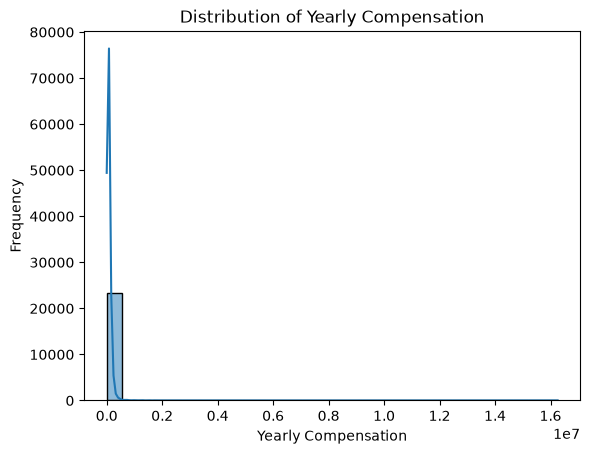

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

#print(df.columns)


sns.histplot(df['ConvertedCompYearly'], bins= 30, kde=True)

plt.title('Distribution of Yearly Compensation')
plt.xlabel('Yearly Compensation')
plt.ylabel('Frequency')
#plt.xlim(0, 300000)
plt.show()

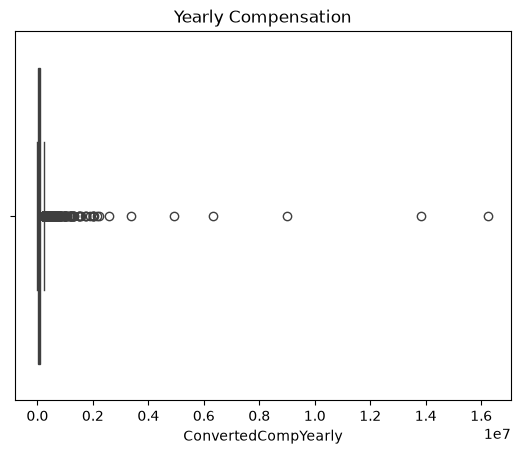

In [22]:

sns.boxplot(x=df['ConvertedCompYearly'])

plt.title('Yearly Compensation')
plt.show()

<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11-05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-09-27|1.1|Madhusudhan Moole|Updated lab|
|2024-09-26|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
